# Agent Pilot Figure

Generates **`results/analysis/figures/agent_pilot.pdf`** — the two-panel figure
used in the Discussion section of the paper.

**Run after:** `08-pilot-agent-trajectories.sh`

**Inputs:**
- `results/agents/agent_pilot_summary.csv`
- `results/agents/agent_option_counts.txt`

**Output:**
- `results/analysis/figures/agent_pilot.pdf`

In [ ]:
# Import Required Libraries
from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [ ]:
# Configure Figure Output Settings
HERE = Path.cwd()
BASE = HERE
while not (BASE / 'results' / 'analysis').exists() and BASE != BASE.parent:
    BASE = BASE.parent

FIG = BASE / 'results' / 'analysis' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
AGENTS = BASE / 'results' / 'agents'

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.labelsize': 9.5, 'axes.labelcolor': '#222222',
    'axes.edgecolor': '#bbb', 'axes.linewidth': 0.6,
    'xtick.color': '#3c4043', 'ytick.color': '#3c4043',
    'xtick.labelsize': 8.5, 'ytick.labelsize': 9,
    'text.color': '#202124',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 150, 'savefig.bbox': 'tight', 'pdf.fonttype': 42,
})

# Vivid colorblind-safe palette
C_LLAMA   = '#9467BD'   # purple (SWE-agent / Llama 70B)
C_KIMI    = '#E377C2'   # pink (DeepSWE-Agent / Kimi K2)
C_HUMAN   = '#1F77B4'   # blue (human authors)
C_MODEL   = '#FF7F0E'   # orange (static model)
C_EXPERT  = '#2CA02C'   # green (expert / kernel)

print('Output directory:', FIG)


Output directory: /home/ternava/Documents/GitHub/llms-miss/results/analysis/figures


In [ ]:
# Load and Prepare Data

# Panel (a): reach by cohort
# Two executing agents + three reference cohorts (from RQ1/RQ2 analysis).
# Reach = distinct valid (unit, option) pairs observed / total GT options (2716).

cohort_labels = [
    'SWE-agent\n(Llama 70B)',
    'DeepSWE-Agent\n(Kimi K2)',
    'Human\nauthors',
    'Static\nmodel',
    'Expert\n(kernel)',
]
reach_pct   = [0.63, 1.33, 5.38, 5.45, 7.03]
invocations = [1779, 14369, 4837, 8795, 15271]
colors_a    = [C_LLAMA, C_KIMI, C_HUMAN, C_MODEL, C_EXPERT]

# Panel (b): option concentration by agent
# Six options that span the two agents' top profiles, showing divergent styles.
# Percentages are share of valid option occurrences per agent.

options_b  = ['ls -F', 'find -name', 'grep -r', 'grep -n', 'grep -A', 'find -type']
# Llama 70B shares  (682, 250, 173, 6, 0, 5  out of ~1248 valid occurrences)
llama_pct  = [54.6, 20.0, 13.9,  0.5,  0.0,  0.4]
# Kimi K2 shares    (≈0,  2400, 2647, 3876, 1619, 1382 out of ~17858 valid occurrences)
kimi_pct   = [ 0.0, 13.4, 14.8, 21.7,  9.1,  7.7]


Saved: /home/ternava/Documents/GitHub/llms-miss/results/analysis/figures/agent_pilot.pdf


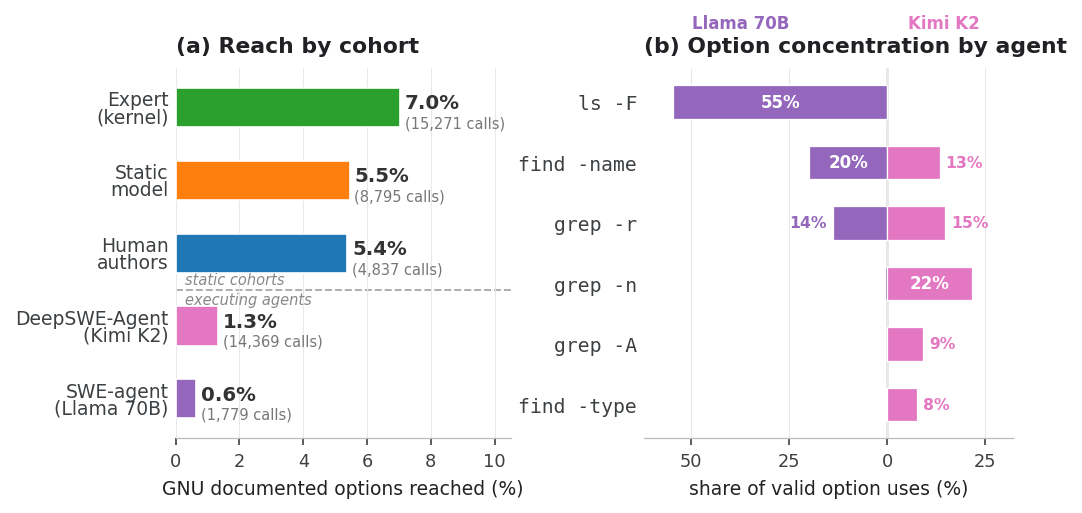

In [ ]:
# Generate and Save Figure

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.2),
                                gridspec_kw={'width_ratios': [1.0, 1.1]})
fig.subplots_adjust(wspace=0.38)

# Panel (a): Reach by cohort
y = np.arange(len(cohort_labels)) * 1.3  # extra vertical spacing for two-line labels

bars = ax1.barh(y, reach_pct, color=colors_a, height=0.7, edgecolor='white', linewidth=0.8)

# Labels with invocation count
for yi, (v, n) in zip(y, zip(reach_pct, invocations)):
    ax1.text(v + 0.15, yi + 0.08, f'{v:.1f}%', va='center', ha='left',
             fontsize=9.5, fontweight='bold', color='#333')
    ax1.text(v + 0.15, yi - 0.28, f'({n:,} calls)', va='center', ha='left',
             fontsize=7, color='#777')

ax1.set_yticks(y)
ax1.set_yticklabels(cohort_labels, fontsize=9, linespacing=0.85)
ax1.set_xlabel('GNU documented options reached (%)', fontsize=9)
ax1.set_xlim(0, 10.5)
ax1.set_ylim(-0.7, y[-1] + 0.7)
ax1.tick_params(axis='y', length=0)
ax1.spines['left'].set_visible(False)

# Dashed separator between agents and reference cohorts
sep_y = (y[1] + y[2]) / 2
ax1.axhline(sep_y, color='#aaa', linewidth=0.9, linestyle='--', zorder=0)
ax1.text(0.3, sep_y - 0.05, 'executing agents', ha='left', va='top',
         fontsize=7, color='#888', style='italic')
ax1.text(0.3, sep_y + 0.05, 'static cohorts', ha='left', va='bottom',
         fontsize=7, color='#888', style='italic')

# Light vertical grid
ax1.set_axisbelow(True)
ax1.xaxis.grid(True, color='#e8e8e8', linewidth=0.5)
ax1.set_title('(a) Reach by cohort', fontsize=10.5, loc='left', pad=8)

# Panel (b): Butterfly chart — option concentration by agent
y2 = np.arange(len(options_b))[::-1]

# Llama bars go left (negative), Kimi bars go right (positive)
bars_llama = ax2.barh(y2, [-v for v in llama_pct], height=0.55,
                       color=C_LLAMA, edgecolor='white', linewidth=0.6)
bars_kimi = ax2.barh(y2, kimi_pct, height=0.55,
                      color=C_KIMI, edgecolor='white', linewidth=0.6)

# Labels on each bar (outside for narrow bars, inside for wide ones)
for yi, (vl, vk) in zip(y2, zip(llama_pct, kimi_pct)):
    if vl > 15:
        ax2.text(-vl / 2, yi, f'{vl:.0f}%', va='center', ha='center',
                 fontsize=8, color='white', fontweight='bold')
    elif vl > 0.5:
        ax2.text(-vl - 1.5, yi, f'{vl:.0f}%', va='center', ha='right',
                 fontsize=7.5, color=C_LLAMA, fontweight='bold')
    if vk > 15:
        ax2.text(vk / 2, yi, f'{vk:.0f}%', va='center', ha='center',
                 fontsize=8, color='white', fontweight='bold')
    elif vk > 0.5:
        ax2.text(vk + 1.5, yi, f'{vk:.0f}%', va='center', ha='left',
                 fontsize=7.5, color=C_KIMI, fontweight='bold')

# Option labels on the left y-axis
ax2.set_yticks(y2)
ax2.set_yticklabels(options_b, fontsize=9.5, fontfamily='monospace')

ax2.set_xlim(-62, 32)
ax2.set_xlabel('share of valid option uses (%)', fontsize=9)
ax2.spines['left'].set_visible(False)
ax2.tick_params(axis='y', length=0)

# Custom x-axis labels (absolute values)
xticks = [-50, -25, 0, 25]
ax2.set_xticks(xticks)
ax2.set_xticklabels([f'{abs(x)}' for x in xticks], fontsize=8.5)

# Arrow annotations showing direction
ax2.annotate('', xy=(-55, len(options_b) - 0.15), xytext=(-20, len(options_b) - 0.15),
             arrowprops=dict(arrowstyle='->', color=C_LLAMA, lw=1.5))
ax2.text(-37.5, len(options_b) + 0.15, 'Llama 70B', ha='center', va='bottom',
         fontsize=8, color=C_LLAMA, fontweight='bold')

ax2.annotate('', xy=(24, len(options_b) - 0.15), xytext=(5, len(options_b) - 0.15),
             arrowprops=dict(arrowstyle='->', color=C_KIMI, lw=1.5))
ax2.text(14.5, len(options_b) + 0.15, 'Kimi K2', ha='center', va='bottom',
         fontsize=8, color=C_KIMI, fontweight='bold')

# Vertical center line
ax2.axvline(0, color='#999', linewidth=0.7, zorder=0)

# Light grid
ax2.set_axisbelow(True)
ax2.xaxis.grid(True, color='#e8e8e8', linewidth=0.5)
ax2.set_title('(b) Option concentration by agent', fontsize=10.5, loc='left', pad=8)

# Save
out = FIG / 'agent_pilot.pdf'
fig.savefig(out)
fig.savefig(FIG / 'agent_pilot.png', dpi=200)
print(f'Saved: {out}')
plt.show()
